# Bài toán: Phân biệt mẫu khác thường


## Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from taxi_preprocessing import preprocess_taxi_df, clean_invalid_data
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load raw data

In [2]:
taxi_df = pd.read_csv('../data/raw/yellow_tripdata_2016-03.csv')

taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80


In [4]:
import pandas as pd
import gc

# Giả sử df là DataFrame lớn
del taxi_df

# Chạy trình thu gom rác để đảm bảo bộ nhớ được giải phóng
gc.collect()

29

## Visualize các mẫu bất thường

### Mẫu có tọa độ bất thường

In [3]:
zero_coords = (
    (taxi_df['pickup_longitude'] == 0) | (taxi_df['pickup_latitude'] == 0)  
)

newyork_coords = (
    (
        (taxi_df['pickup_longitude'] >= -74.27) &
        (taxi_df['pickup_longitude'] <= -73.68)
    ) &
    (
        (taxi_df['pickup_latitude'] >= 40.49) &
        (taxi_df['pickup_latitude'] <= 40.92)
    )
)

outside = (~newyork_coords)  & (~zero_coords)
zero = zero_coords


c:\Users\MSI VN\.conda\envs\seminar_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


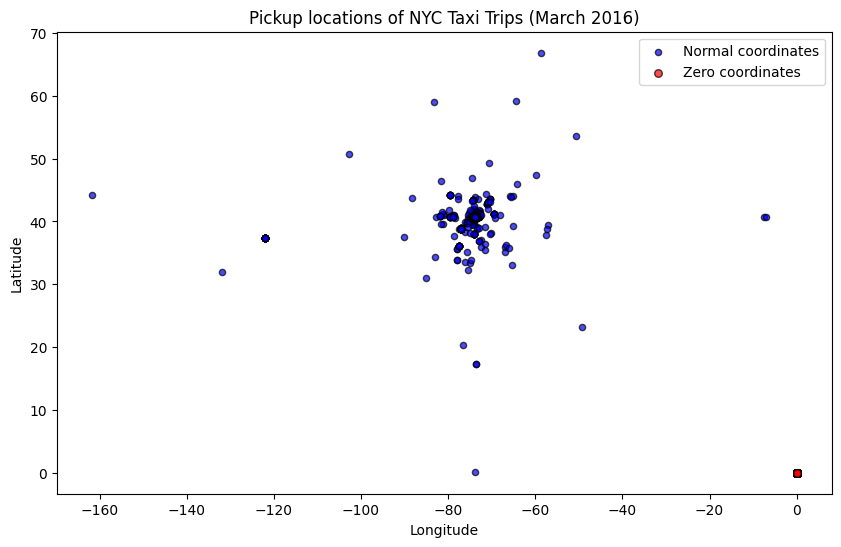

In [14]:
plt.figure(figsize=(10, 6))

normal = ~zero_coords 

# normal
plt.scatter(
    taxi_df.loc[normal , 'pickup_longitude'], 
    taxi_df.loc[normal , 'pickup_latitude'], 
    alpha=0.7,
    color='blue',
    s=20,
    label='Normal coordinates',
    edgecolors='black',
    zorder=1
)

# zero
plt.scatter(
    taxi_df.loc[zero_coords, 'pickup_longitude'],
    taxi_df.loc[zero_coords, 'pickup_latitude'],
    alpha=0.7,
    color='red',
    s=30,
    edgecolors='black',
    label='Zero coordinates',
    zorder=2
)

plt.title('Pickup locations of NYC Taxi Trips (March 2016)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

* Ta nhận thấy được có những điểm đỏ là những điểm có tọa độ = 0 là các điểm tọa độ bất thường vì chúng ko hề nằm trong phạm vi thành phố New York hay Mỹ mà nằm ở ngoài Đại Tây Dương
* Có những điểm khác nằm khá xa NYC được xem là bất hợp lý và hầu hết được xuất hiện do lỗi dữ liệu, các mẫu lỗi cần được xử lý để làm sạch dữ liệu trước khi đưa vào các mô hình dựa đoán

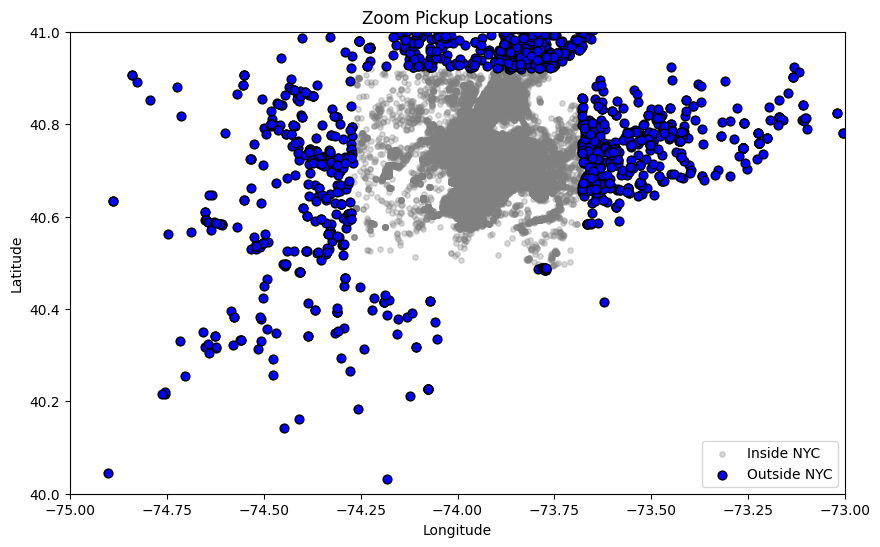

In [16]:
plt.figure(figsize=(10, 6))

normal = newyork_coords 

# normal
plt.scatter(
    taxi_df.loc[normal, 'pickup_longitude'], 
    taxi_df.loc[normal, 'pickup_latitude'], 
    alpha=0.3,
    color='gray',
    s=15,
    label='Inside NYC',
    zorder=1
)


outside
plt.scatter(
    taxi_df.loc[outside, 'pickup_longitude'],
    taxi_df.loc[outside, 'pickup_latitude'],
    alpha=1,
    color='blue',
    s=40,
    edgecolors='black',
    label='Outside NYC',
    zorder=2
)


plt.title('Zoom Pickup Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-75, -73)
plt.ylim(40, 41)
plt.legend()
plt.show()

* Ngoài những cuốc trong phạm vi thành phố New York thì ta thấy được có nhiều cuốc xe năm ngoài tọa độ thành phố nhưng nó không quá xa, ta vẫn có thể giữ lại các mẫu này để có nhiều thông tin hơn cho việc dự đoán

c:\Users\MSI VN\.conda\envs\seminar_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


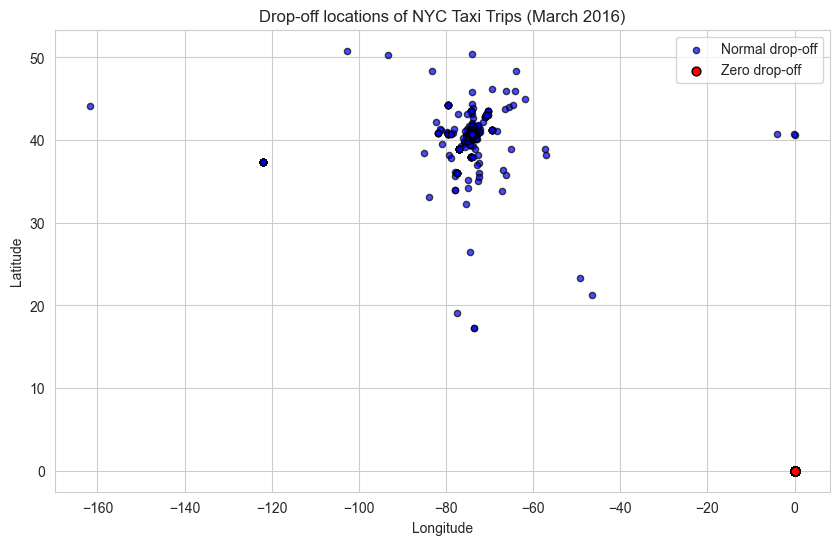

In [4]:
zero_coords_drop_off = (
    (taxi_df['dropoff_longitude'] == 0) | (taxi_df['dropoff_latitude'] == 0)
)

normal_drop_off = ~zero_coords_drop_off

plt.figure(figsize=(10, 6))
plt.scatter(
    taxi_df.loc[normal_drop_off, 'dropoff_longitude'], 
    taxi_df.loc[normal_drop_off, 'dropoff_latitude'], 
    alpha=0.7,
    color='blue',
    s=20,
    label='Normal drop-off',
    edgecolors='black',
    zorder=1
)
plt.scatter(
    taxi_df.loc[zero_coords_drop_off, 'dropoff_longitude'],
    taxi_df.loc[zero_coords_drop_off, 'dropoff_latitude'],
    alpha=1,
    color='red',
    s=40,
    edgecolors='black',
    label='Zero drop-off',
    zorder=2
)
plt.title('Drop-off locations of NYC Taxi Trips (March 2016)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()


* Ngoài ra ở điểm đón ta cũng thấy có những điểm tọa độ khá bất thường, có những điểm đón có tọa độ bằng 0 hoặc quá xa so với thành phố New York, ta sẽ xem xét các mẫu để làm sạch dữ liệu

### Những cột có dữ liệu bất thường

### 1. Cột trip_distance

In [32]:
print('Top 10 chuyến xe taxi dài nhất: ')
taxi_df['trip_distance'].sort_values(ascending=False).head(10)

Top 10 chuyến xe taxi dài nhất: 


8340109     19072628.8
10213817     8330083.2
278064       5000000.0
4125998      1663428.0
4695610       800000.2
10276196      530849.5
4238311       452310.8
5293144       318000.0
6400141       308228.5
10727702      300833.1
Name: trip_distance, dtype: float64

* Có nhiều chuyến xe có quãng đường đi rất dài và đây là các mẫu bất thường cần được xử lý 

In [7]:
print('Số lượng chuyến xe có khoảng cách âm hoặc bằng 0: ')
invalid_distance = taxi_df[taxi_df['trip_distance'] <= 0]
print(invalid_distance.shape[0])

Số lượng chuyến xe có khoảng cách âm hoặc bằng 0: 
71126


* Dữ liệu tồn tại 1 lượng lớn chuyến xe có khoảng cách nhỏ hơn hoặc bằng 0, đây là các mẫu bất thường và cần được xử lý để giảm bớt nhiễu cho mô hình dự đoán

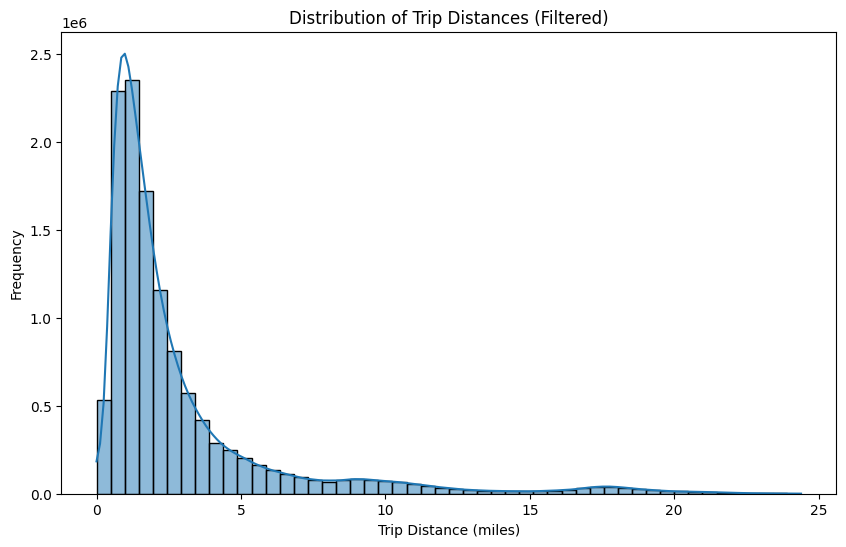

In [4]:
taxi_filtered = taxi_df[taxi_df['trip_distance'] < taxi_df['trip_distance'].quantile(0.999)]
plt.figure(figsize=(10, 6))
sns.histplot(taxi_filtered['trip_distance'], bins=50, kde=True)
plt.title('Distribution of Trip Distances (Filtered)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.show()

* Phân phối khoảng cách chuyến đi có dạng lệch phải, với phần lớn các chuyến đi có khoảng cách ngắn và một số ít chuyến có khoảng cách rất dài
* Phân phối của trip_distance cho thấy được đa số các chuyến xe có chiều dài dưới 5 dặm, số ít có những cuốc xe khá xa trên 20 dặm 
* Biểu đồ cho thấy tần suất chuyến xe giảm nhanh khi chuyến xe càng xa, cho thấy được rằng đa số taxi New York có xu hướng đi trong nội đô thành phố và các chuyến đi dài ra ngoại ô hoặc các thành phố khác khá hiếm

### 2. Cột fare_amount

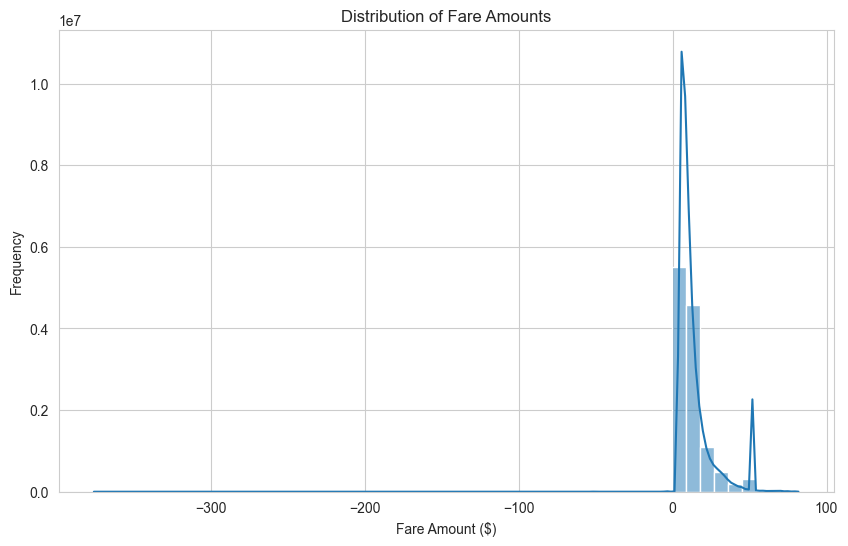

In [5]:
fare_filtered = taxi_df[taxi_df['fare_amount'] < taxi_df['fare_amount'].quantile(0.999)]
plt.figure(figsize=(10, 6))
sns.histplot(fare_filtered['fare_amount'], bins=50, kde=True)
plt.title('Distribution of Fare Amounts')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.show()


* Biểu đồ có các giá trị âm, đây có thể là các giá trị lỗi vì cước giá âm thì rất vô lý
* Bỏ qua các giá trị âm thì ta thấy được phân phối của đồ thị đang lệch phải, với phần lớn cước phí chuyến xe rơi vào tầm 10-20$
* Các cuốc xe có cước phí cao hơn có tần suất khá thấp cho thấy được xu hướng của các chuyến taxi chỉ đi trong nội đô thành phố


In [5]:
taxi_df['fare_amount'].sort_values(ascending=False).head(10)

8927590     429496.72
6741042     133065.37
6521510     126348.88
9039113       2002.50
3353214       1426.00
12019760      1120.50
1991212       1116.50
5983933       1000.00
8378956        963.00
8378578        952.00
Name: fare_amount, dtype: float64

* Ngoài ra, ta thấy có những cuốc xe taxi có cước giá trên trời, ta cần phân tích các mẫu này với các cột trip_distance và trip_duration để có nhận biết được các bất thường trong các chuyến xe này

### 3. Cột passenger_count

In [7]:
taxi_df['passenger_count'].value_counts()

passenger_count
1    8690240
2    1730864
5     644712
3     499376
6     405255
4     239827
0        608
7         24
8         24
9         22
Name: count, dtype: int64

* Ta thấy phần lớn chuyến taxi chỉ có 1 hành khách, cho thấy nhu cầu di chuyển cá nhân chiếm phần lớn trong dữ liệu
* Các chuyến đi với 5–6 hành khách vẫn xuất hiện với tần suất đáng kể, có thể liên quan đến taxi cỡ lớn hoặc các nhóm di chuyển cùng nhau.
* Tần suất chuyến đi giảm dần khi số lượng hành khách tăng, phản ánh việc di chuyển nhóm lớn ít phổ biến hơn
* Có số ít chuyến có 0 hành khách, đây có là lỗi dữ liệu trong quá trình ghi nhận
* Các chuyến xe có nhiều hơn 6 hành khách có thể được xem là các giá trị bất thường vì các taxi NYC chỉ chứa tối đa được 6 người

### 4. Các cột datetime

In [14]:
taxi_df[taxi_df['tpep_pickup_datetime'] == taxi_df['tpep_dropoff_datetime']]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80
5,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,5.92,-74.017197,40.705383,1,N,-73.978073,40.755787,1,23.5,1.0,0.5,5.06,0.00,0.3,30.36
6,2,2016-03-01 00:00:00,2016-03-01 00:00:00,6,5.72,-73.994583,40.727848,1,N,0.000000,0.000000,2,23.0,0.5,0.5,0.00,0.00,0.3,24.30
20904,2,2016-03-10 08:57:08,2016-03-10 08:57:08,1,0.01,-73.928329,40.759708,1,N,-73.869072,40.773022,2,2.5,0.0,0.5,0.00,0.00,0.3,3.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12207125,1,2016-03-31 23:48:00,2016-03-31 23:48:00,1,0.00,0.000000,0.000000,1,N,0.000000,0.000000,2,2.5,0.5,0.5,0.00,0.00,0.3,3.80
12208277,1,2016-03-31 23:51:25,2016-03-31 23:51:25,1,0.00,-73.981339,40.784496,1,N,0.000000,0.000000,2,8.0,0.5,0.5,0.00,0.00,0.3,9.30
12209016,1,2016-03-31 23:53:41,2016-03-31 23:53:41,1,0.00,-74.005081,40.719769,1,Y,0.000000,0.000000,2,19.0,0.5,0.5,0.00,0.00,0.3,20.30
12210431,2,2016-03-31 23:58:15,2016-03-31 23:58:15,1,1.10,-73.999687,40.675900,5,N,-73.991570,40.664398,2,23.3,0.0,0.0,0.00,0.00,0.3,23.60


* Một số bản ghi có thời gian bắt đầu và kết thúc trùng nhau, dẫn đến thời gian chuyến đi bằng 0. Các trường hợp này được xem là dữ liệu bất thường do không phản ánh đúng thực tế vận hành của taxi
* Các mẫu này có thể phát sinh do các lỗi hệ thống khiến dữ liệu các cuốc xe bị hủy vẫn được lưu trong hệ thống

## Xử lý các mẫu dữ liệu lỗi

### Qua quá trình khai phá các bất thường trong dữ liệu, ta nhận thấy rằng có khá nhiều dữ liệu lỗi và không hợp lệ nên ta sẽ tiến hành xóa các dữ liệu này để tránh việc gây nhiễu cho các mô hình về sau

In [3]:
df_processed = preprocess_taxi_df(taxi_df)

df_processed.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,...,trip_duration,speed,pickup_hour,pickup_dayofweek,pickup_month,time_of_day,is_peak_hour,fare_per_miles,is_credit_card,total_income
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,...,475.0,18.947368,0,1,3,night,0,3.600000,1,11.05
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,...,666.0,15.675676,0,1,3,night,0,3.793103,1,14.05
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,...,1866.0,38.546624,0,1,3,night,0,2.727728,1,62.50
7,1,2016-03-01 00:00:01,2016-03-01 00:16:04,1,6.20,-73.788773,40.647758,1,N,-73.829208,...,963.0,23.177570,0,1,3,night,0,3.306452,0,20.50
8,1,2016-03-01 00:00:01,2016-03-01 00:05:00,1,0.70,-73.958221,40.764641,1,N,-73.967896,...,299.0,8.428094,0,1,3,night,0,7.857143,1,7.50
9,2,2016-03-01 00:00:01,2016-03-01 00:24:06,3,7.18,-73.985779,40.741192,1,N,-73.946350,...,1445.0,17.887889,0,1,3,night,0,3.272981,1,26.70
10,2,2016-03-01 00:00:01,2016-03-01 00:02:03,2,0.54,-73.988426,40.764160,1,N,-73.992393,...,122.0,15.934426,0,1,3,night,0,7.407407,0,4.00
11,1,2016-03-01 00:00:02,2016-03-01 00:07:49,1,1.70,-73.969818,40.797428,1,N,-73.943771,...,467.0,13.104925,0,1,3,night,0,4.705882,0,8.00
12,1,2016-03-01 00:00:02,2016-03-01 00:03:05,1,1.10,-73.953804,40.788128,1,N,-73.971550,...,183.0,21.639344,0,1,3,night,0,5.000000,1,7.70
13,2,2016-03-01 00:00:02,2016-03-01 00:09:32,1,2.10,-73.976089,40.752171,1,N,-73.987450,...,570.0,13.263158,0,1,3,night,0,4.285714,1,11.06


In [4]:
print(f'Số lượng chuyến xe ban đầu: {len(taxi_df)}')
print(f'Sau khi làm sạch dữ liệu, số lượng chuyến xe còn lại: {len(df_processed)}')

Số lượng chuyến xe ban đầu: 12210952
Sau khi làm sạch dữ liệu, số lượng chuyến xe còn lại: 11927906


## Tiến hành sử dụng mô hình để dự đoán bất thường

### 1. Chọn input feature

In [7]:
input_features = ['trip_distance', 'trip_duration', 'fare_amount', 'speed', 'passenger_count', 'fare_per_miles']

### 2. Tìm ra ngưỡng cho các cột

In [8]:
def get_threshold(series):
    low_q = series.quantile(0.01)
    high_q = series.quantile(0.99)

    return low_q, high_q

thresholds = {}

for col in input_features:
    low, high = get_threshold(df_processed[col])
    thresholds[col] = (low, high)
    print(f"{col}: {low:.2f} -> {high:.2f}")

trip_distance: 0.30 -> 18.60
trip_duration: 104.00 -> 3165.00
fare_amount: 3.50 -> 52.00
speed: 3.36 -> 34.24
passenger_count: 1.00 -> 6.00
fare_per_miles: 2.77 -> 15.00


- Sau khi tính các ngưỡng ta thấy được các cột đã được tính khá hợp lý so với logic dữ liệu, nhưng ta cần xem xét lại phân phối các cột để coi các ngưỡng đã hợp lý hay chưa

### Phân phối fare_per_miles

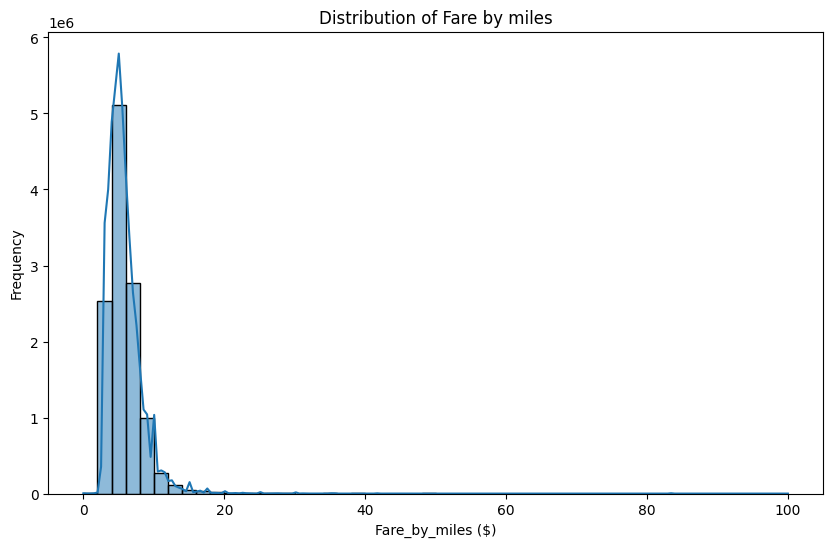

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df_processed.loc[df_processed['fare_per_miles'] < 100, 'fare_per_miles'], bins=50, kde=True)
plt.title('Distribution of Fare by miles')
plt.xlabel('Fare_by_miles ($)')
plt.ylabel('Frequency')
plt.show()

* Nhìn vào biểu đồ ta thấy được đa số các chuyến xe có fare_per_miles nằm trong khoảng (2,20). Các giá trị sau đó xuất hiện rất hiếm và có thể xem là mẫu bất thường. 
* Ta chọn ngưỡng trên của cột là 20 vì các giá trị này xuất hiện khá ít và có thể xem là bất thường
* Ta chọn ngưỡng dưới là 2 vì các chuyến thấp hơn rất ít xảy ra trong thực tế

### Phân phối cột speed


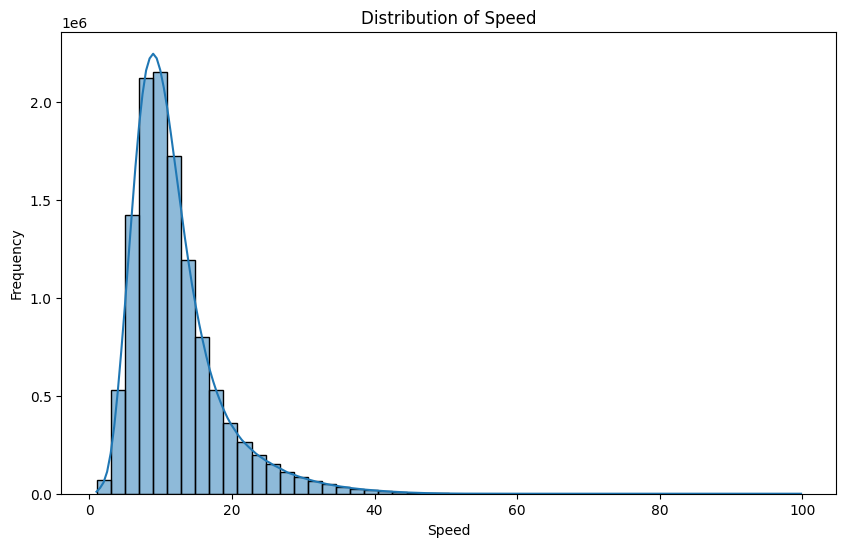

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['speed'], bins=50, kde=True)
plt.title('Distribution of Speed')
plt.xlabel('Speed')
plt.ylabel('Frequency')
plt.show()

* Phân phối vận tốc cho thấy phần lớn chuyến đi nằm trong khoảng 5–25 mph, phản ánh đúng với điều kiện giao thông trong thành phố, các vận tốc lớn hơn 25mph có thể là đang chạy trên cao tốc hoặc quốc lộ nhưng trên 60 mph thì được xem là bất thường vì tốc độ vượt quá quy định cho phép. Tương tự với đó thì các mẫu có vận tốc dưới 2 mph thì cũng được xem là bât thường vì xe đi quá chậm.

### Phân phối cột fare

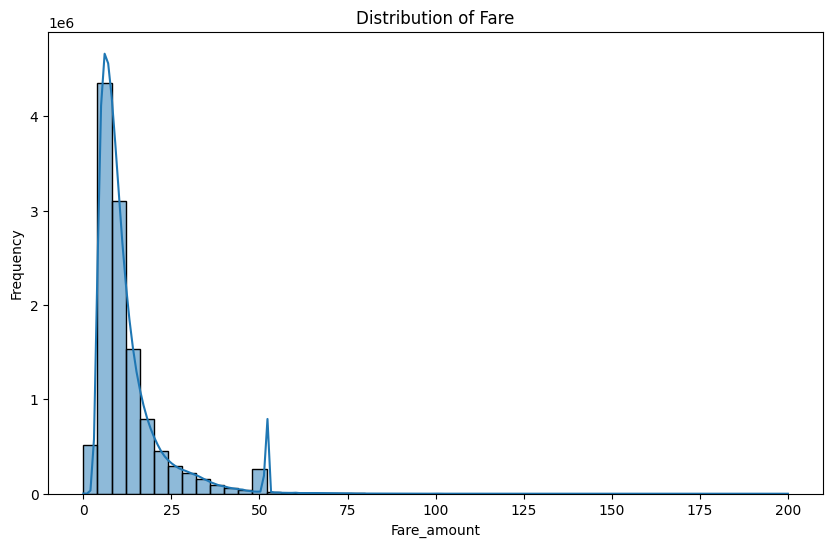

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_processed.loc[df_processed['fare_amount'] < 200, 'fare_amount'], bins=50, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare_amount')
plt.ylabel('Frequency')
plt.show()

* Phân phối giá cước cho thấy phần lớn chuyến đi có mức giá dưới 30 USD, trong khi một cụm giá cố định khoảng 52 USD (Chưa bao gồm tip và phí cầu đường) phản ánh các chuyến đi đặc biệt như sân bay. Cho nên ta sẽ chọn các chuyến xe có cước phí hơn 100 USD làm các bất thường trong dữ liệu.
* Biểu đồ cho ra base fare là 2.5 USD nên ta chọn các mẫu có dữ liệu dưới 2.5 làm mẫu bất thường

### Phân phối cột Trip_distance

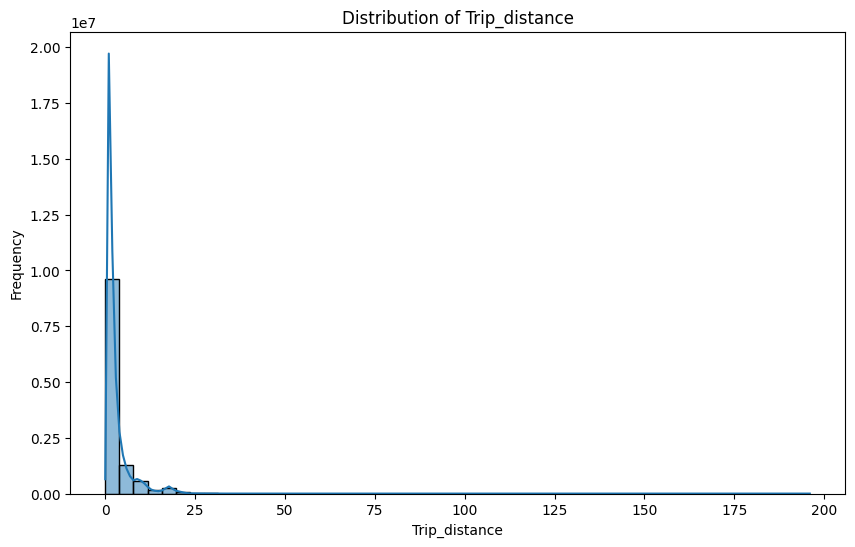

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_processed.loc[df_processed['trip_distance'] < 200, 'trip_distance'], bins=50, kde=True)
plt.title('Distribution of Trip_distance')
plt.xlabel('Trip_distance')
plt.ylabel('Frequency')
plt.show()

* Phân phối khoảng cách của biểu đồ phần lớn có chuyến đi từ 0 đến 10 dặm phản ánh đúng với nhu cầu di chuyển ngắn trong thành phố, các chuyến có khoảng cách dài hơn xuất hiện khá ít, ta chọn các mẫu bất thường là các mẫu có khoảng cách trên 50 dặm vì nằm ngoài phạm vi thành phố

### Phân phối cột Trip_duration

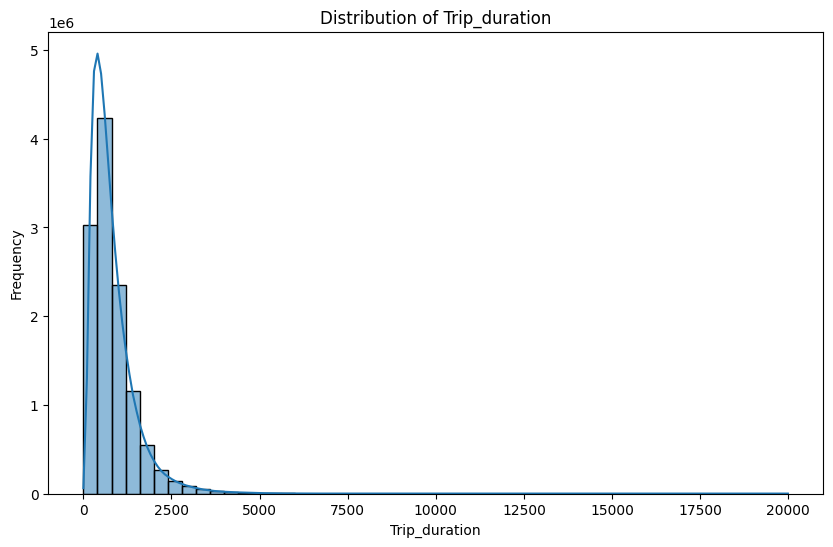

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_processed.loc[df_processed['trip_duration'] < 20000,'trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip_duration')
plt.xlabel('Trip_duration')
plt.ylabel('Frequency')
plt.show()

* Phân phối biểu đồ cho thấy phần lớn các chuyến xe có khoảng thời gian đi trong 5000 giây đổ lại (Khoảng hơn 1 tiếng), đa số các chuyến xe chỉ có thgian di chuyển cỡ từ 0 đến 1000s phản ánh đúng nhu cầu di chuyển trong thành phố.
* Các chuyến có từ 10000s trở lên được xem là bất thường vì quá lâu cho một chuyến taxi
* Các chuyến có từ 60s trở xuống cũng được xem là bất thường vì quá nhanh

In [ ]:
thresholds['fare_per' \
'_miles'] = (2, 20)
thresholds['speed'] = (2, 60)
thresholds['fare_amount']= (2.5, 100)
thresholds['trip_distance'] = (0, 50)
thresholds['trip_duration'] = (60, 10000)

### 3. Rule_based phân tích các mẫu bất thường

In [29]:
def detect_rule_anomaly(df, thresholds):
    condition = False

    for col, (low, high) in thresholds.items():
        condition |= (df[col] < low) | (df[col] > high)

    return condition

df_processed['rule_anomaly'] = detect_rule_anomaly(df_processed, thresholds).astype(int)

In [30]:
print(f"Phần trăm mẫu bất thường trong dataset {df_processed['rule_anomaly'].mean():.2f}")

Phần trăm mẫu bất thường trong dataset 0.01


In [ ]:
df_processed[df_processed['rule_anomaly'] == 1][input_features].head(50)

NameError: name 'df_processed' is not defined

### 4. Sử dụng mô hình IsolationForest

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed[input_features])

model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

df_processed['model_anomaly'] = model.fit_predict(X_scaled)
df_processed['model_anomaly'] = (df_processed['model_anomaly'] == -1).astype(int)

In [19]:
print(f"Kết quả mô hình dự đoán\nPhần trăm mẫu bất thường trong dataset: {df_processed['model_anomaly'].mean():.2f} ")

Kết quả mô hình dự đoán
Phần trăm mẫu bất thường trong dataset: 0.01 


In [20]:
anomalies = df_processed[df_processed['model_anomaly'] == 1]

In [23]:
anomalies[input_features].head(20)

,trip_distance,trip_duration,fare_amount,speed,passenger_count,pickup_hour,fare_per_miles
2,19.98,1866.0,54.50,38.546624,2,0,2.727728
18,16.81,1962.0,52.00,30.844037,3,0,3.093397
62,9.46,911.0,26.50,37.383095,6,0,2.801268
64,19.35,2260.0,52.00,30.823009,1,0,2.687339
129,18.34,2343.0,58.34,28.179257,3,0,3.181025
131,20.20,2369.0,52.00,30.696496,1,0,2.574257
135,18.95,2245.0,52.00,30.387528,2,0,2.744063
148,18.90,2162.0,52.00,31.470860,1,0,2.751323
170,18.30,1895.0,52.00,34.765172,1,0,2.841530
427,19.57,5497.0,52.00,12.816445,6,7,2.657128


### 5. So sánh mô hình với Rule_based

In [32]:
from sklearn.metrics import classification_report

y_true = df_processed['rule_anomaly']
y_pred = df_processed['model_anomaly']

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95  11031214
           1       0.44      0.47      0.46    896692

    accuracy                           0.92  11927906
   macro avg       0.70      0.71      0.70  11927906
weighted avg       0.92      0.92      0.92  11927906



In [33]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_true, y_pred))

[[10498597   532617]
 [  475076   421616]]
